In [ ]:
!pip install -q kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 96% 633M/658M [00:01<00:00, 300MB/s]
100% 658M/658M [00:01<00:00, 396MB/s]


In [ ]:
!unzip -q plantdisease.zip

In [ ]:
import os

data_dir = "/content/PlantVillage"

print("Number of classes:", len(os.listdir(data_dir)))
print("Sample classes:", os.listdir(data_dir)[:5])

Number of classes: 15
Sample classes: ['Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Leaf_Mold']


In [ ]:
class_counts = {}

for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

for k, v in class_counts.items():
    print(k, ":", v)

Tomato__Target_Spot : 1404
Tomato_Bacterial_spot : 2127
Pepper__bell___Bacterial_spot : 997
Tomato__Tomato_mosaic_virus : 373
Tomato_Leaf_Mold : 952
Potato___Late_blight : 1000
Pepper__bell___healthy : 1478
Tomato__Tomato_YellowLeaf__Curl_Virus : 3209
Potato___healthy : 152
Tomato_Late_blight : 1909
Tomato_Spider_mites_Two_spotted_spider_mite : 1676
Potato___Early_blight : 1000
Tomato_healthy : 1591
Tomato_Early_blight : 1000
Tomato_Septoria_leaf_spot : 1771


In [ ]:
import tensorflow as tf

img_size = (256, 256)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 20646 files belonging to 15 classes.
Using 16517 files for training.
Found 20646 files belonging to 15 classes.
Using 4129 files for validation.


In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))


train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(15, activation='softmax')
])


/tmp/ipython-input-1724203595.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [ ]:
# AUTOTUNE=tf.data.AUTOTUNE
# train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
# val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.6978 - loss: 1.0284 - val_accuracy: 0.8861 - val_loss: 0.3755
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9032 - loss: 0.3305 - val_accuracy: 0.8992 - val_loss: 0.2995
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.9275 - loss: 0.2478 - val_accuracy: 0.9113 - val_loss: 0.2658
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9403 - loss: 0.2077 - val_accuracy: 0.9176 - val_loss: 0.2543
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.9493 - loss: 0.1770 - val_accuracy: 0.9234 - val_loss: 0.2345


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save full model (architecture + weights + optimizer state)
model.save("/content/drive/MyDrive/plant_disease_mobilenet_v1.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/plant_disease_mobilenet_v1.keras")
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# Create test dataset (same split logic as training)
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Apply MobileNetV2 preprocessing
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

# Optimize pipeline
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [ ]:
# Temporary dataset to obtain the class names for analysis

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size
)

class_names = temp_ds.class_names

Found 20638 files belonging to 15 classes.


                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.97      0.98       200
                     Pepper__bell___healthy       0.98      0.99      0.98       302
                      Potato___Early_blight       0.99      0.97      0.98       189
                       Potato___Late_blight       0.89      0.97      0.93       188
                           Potato___healthy       0.96      0.87      0.92        31
                      Tomato_Bacterial_spot       0.89      0.96      0.92       441
                        Tomato_Early_blight       0.75      0.77      0.76       191
                         Tomato_Late_blight       0.95      0.91      0.93       341
                           Tomato_Leaf_Mold       0.95      0.77      0.85       185
                  Tomato_Septoria_leaf_spot       0.90      0.86      0.88       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.89      0.89

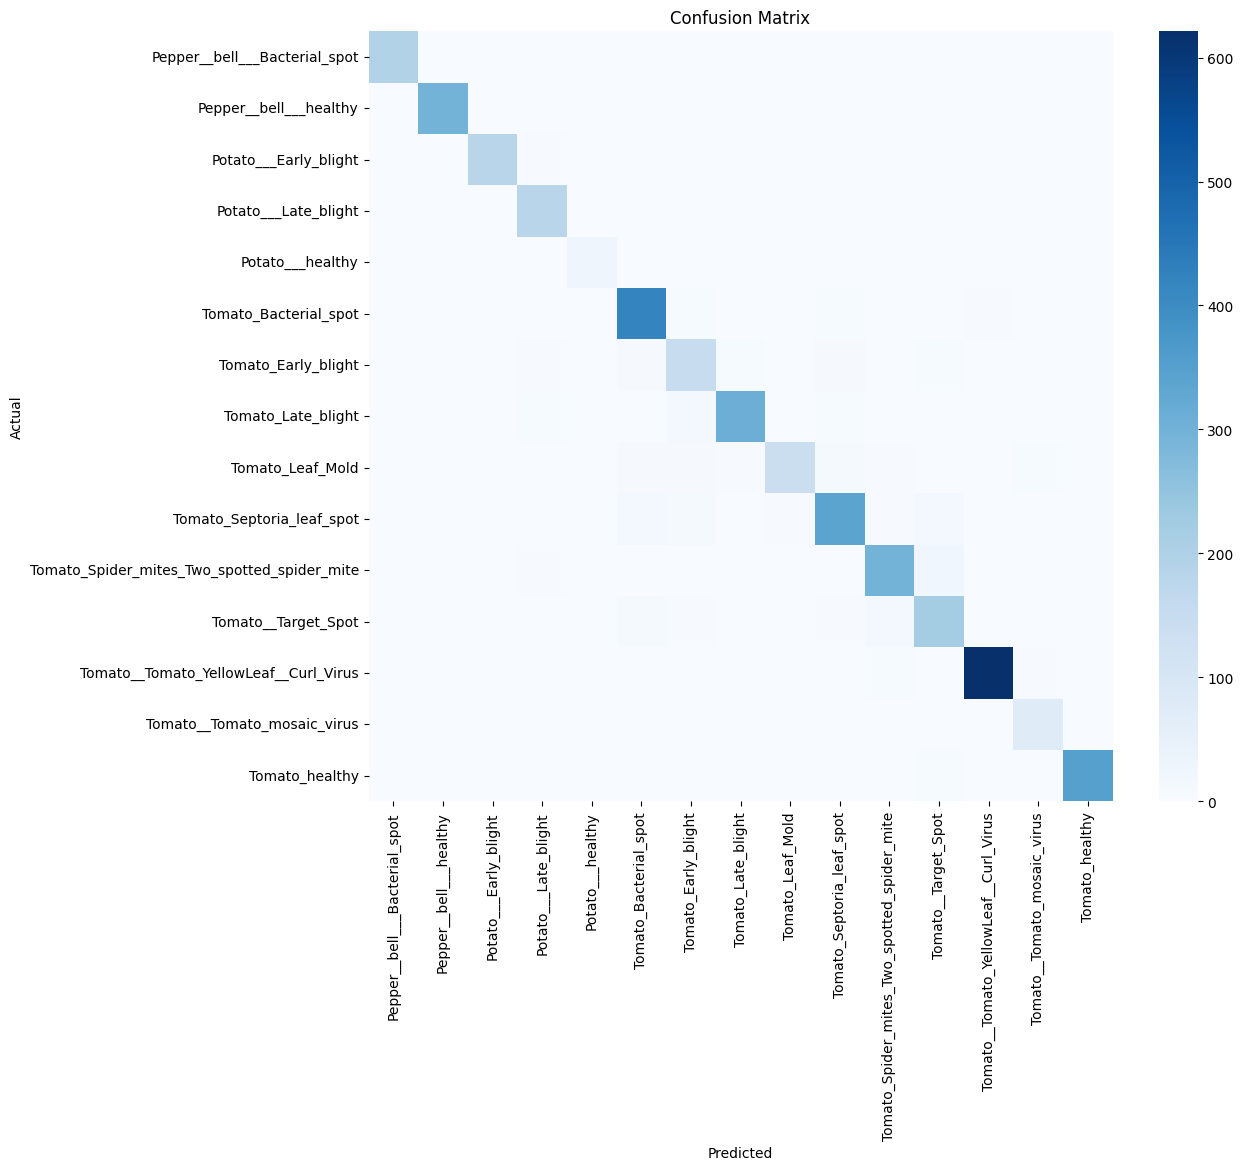

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions and true labels together (single pass)
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = temp_ds.class_names

print("-------CLASSIFICATION REPORT-------")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
recall_per_class

array([0.975     , 0.98675497, 0.97354497, 0.97340426, 0.87096774,
       0.9569161 , 0.77486911, 0.90615836, 0.77297297, 0.86479592,
       0.89156627, 0.8467433 , 0.97949527, 0.96153846, 0.96685083])

In [ ]:
# Printing different layers of the network so as to find the base_model mobilenet_v2

for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.trainable)

0 mobilenetv2_1.00_224 False
1 global_average_pooling2d True
2 dense True


In [ ]:
base_model = model.layers[0]

In [ ]:
# Unfreezing the high - level layers of the CNN

base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable=False

In [ ]:
# Recompilation with a small learning rate

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

ft_history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[early_stop]
)

Epoch 1/6
516/516 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.9852 - loss: 0.0610 - val_accuracy: 0.9569 - val_loss: 0.1286
Epoch 2/6
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9908 - loss: 0.0450 - val_accuracy: 0.9578 - val_loss: 0.1227
Epoch 3/6
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9939 - loss: 0.0364 - val_accuracy: 0.9610 - val_loss: 0.1157
Epoch 4/6
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9971 - loss: 0.0263 - val_accuracy: 0.9624 - val_loss: 0.1111
Epoch 5/6
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step - accuracy: 0.9959 - loss: 0.0228 - val_accuracy: 0.9646 - val_loss: 0.1065
Epoch 6/6
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9975 - loss: 0.0188 - val_accuracy: 0.9663 - val_loss: 0.1011


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9640 - loss: 0.1058
Test Accuracy: 0.9663193821907043


In [ ]:
model

<Sequential name=sequential, built=True>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/plant_disease_finetuned_v2.keras")
print("Fine-tuned model saved successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fine-tuned model saved successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Loading the saved model
model = load_model("/content/drive/MyDrive/plant_disease_mobilenet_v1.keras")

# Recreating class names as before
temp_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/PlantVillage",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32
)

class_names = temp_ds.class_names

def predict_image(img_path):
  img = image.load_img(img_path, target_size=(256,256))
  img_array=image.img_to_array(img)
  img_array=tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
  img_array=np.expand_dims(img_array, axis=0)

  preds = model.predict(img_array)[0]

  top_indices = np.argsort(preds)[-3:][::-1]

  for i in top_indices:
    print(class_names[i], float(preds[i]))


Found 20646 files belonging to 15 classes.
Using 16517 files for training.


In [ ]:
import os

for class_folder in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_folder)
    if os.path.isdir(class_path):
        image_name = os.listdir(class_path)[0]
        image_path = os.path.join(class_path, image_name)
        print(image_path)
        break

In [ ]:
predict_image("/content/PlantVillage/Potato___healthy/ff700844-68ad-4e99-8427-58a39c07f817___RS_HL 1860.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Potato___healthy 0.8886012434959412
Tomato_healthy 0.11080319434404373
Potato___Late_blight 0.0005424607661552727


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving ewt6.jpg to ewt6.jpg


In [ ]:
for filename in uploaded.keys():
  print("\nImage:",filename)
  predict_image(filename)


Image: ewt6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Tomato_Bacterial_spot 0.18350563943386078
Pepper__bell___healthy 0.12700296938419342
Tomato_Septoria_leaf_spot 0.1197175532579422


In [ ]:
# Augmenting the input images to bring their appearance closer to real world images.

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2)
])

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_disease_finetuned_v2.keras"
)

In [ ]:
# Extracting Trained Base
trained_base = model.layers[0]   # This is your MobileNetV2
gap = model.layers[1]
dense = model.layers[2]

In [ ]:
# Define Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [ ]:
# Preserve weights and rebuild using functional APIs
inputs=tf.keras.Input(shape=(224,224,3))

x=data_augmentation(inputs)
x=trained_base(x, training=False)
x=gap(x)
outputs=dense(x)

model=tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3
516/516 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.5696 - loss: 1.6472 - val_accuracy: 0.9152 - val_loss: 0.2650
Epoch 2/3
516/516 ━━━━━━━━━━━━━━━━━━━━ 47s 92ms/step - accuracy: 0.7215 - loss: 0.8514 - val_accuracy: 0.8575 - val_loss: 0.5018
Epoch 3/3
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - accuracy: 0.7702 - loss: 0.6938 - val_accuracy: 0.8214 - val_loss: 0.6438


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_disease_finetuned_v2.keras"
)

In [ ]:
for layer in model.layers:
  layer.trainable=False
model.layers[-1].trainable=True

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

Epoch 1/2
516/516 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.9651 - val_loss: 0.1009
Epoch 2/2
516/516 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9651 - val_loss: 0.1011


In [ ]:
for filename in uploaded.keys():
  print("\nImage:",filename)
  predict_image(filename)


Image: ewt5 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Pepper__bell___Bacterial_spot 0.8411496877670288
Tomato_Early_blight 0.15285441279411316
Pepper__bell___healthy 0.003276722738519311


In [ ]:
model.save("/content/drive/MyDrive/plant_disease_finetuned_augmented_v3.keras")

In [ ]:
for filename in uploaded.keys():
  print("\nImage:",filename)
  predict_image(filename)


Image: ewt6.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Tomato_Leaf_Mold 0.8447983860969543
Tomato_Early_blight 0.07773534953594208
Potato___Late_blight 0.05973276495933533


In [ ]:
import os
print(len(os.listdir("/content/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite")))

1676


In [ ]:
import os
print(len(os.listdir("/content/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite")))

1684


Found 20646 files belonging to 15 classes.
Using 16517 files for training.
Found 20646 files belonging to 15 classes.
Using 4129 files for validation.


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_disease_finetuned_augmented_v3.keras"
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

Epoch 1/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.9981 - loss: 0.0137 - val_accuracy: 0.9707 - val_loss: 0.0915
Epoch 2/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.9981 - loss: 0.0138 - val_accuracy: 0.9709 - val_loss: 0.0919


In [ ]:
img_size = (256, 256)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)


Found 20646 files belonging to 15 classes.
Using 16517 files for training.
Found 20646 files belonging to 15 classes.
Using 4129 files for validation.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(15, activation='softmax')
])


/tmp/ipython-input-1724203595.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 51s 79ms/step - accuracy: 0.3269 - loss: 2.2406 - val_accuracy: 0.7280 - val_loss: 1.1605
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 57s 44ms/step - accuracy: 0.7496 - loss: 1.0314 - val_accuracy: 0.8012 - val_loss: 0.7916
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.8126 - loss: 0.7352 - val_accuracy: 0.8365 - val_loss: 0.6329
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.8513 - loss: 0.5937 - val_accuracy: 0.8586 - val_loss: 0.5426
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8721 - loss: 0.5122 - val_accuracy: 0.8736 - val_loss: 0.4823


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.7327 - loss: 0.8355 - val_accuracy: 0.8830 - val_loss: 0.3774
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.9075 - loss: 0.3139 - val_accuracy: 0.9097 - val_loss: 0.2908
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9369 - loss: 0.2206 - val_accuracy: 0.9315 - val_loss: 0.2255
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9540 - loss: 0.1701 - val_accuracy: 0.9431 - val_loss: 0.1830
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9683 - loss: 0.1284 - val_accuracy: 0.9496 - val_loss: 0.1562


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_disease_finetuned_augmented_v3.keras"
)

In [ ]:
# USing gradcam to check where exactly the model has looked while making predictions


import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def gradcam(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    img = cv2.imread(img_path)
    img = cv2.resize(img,(224,224))

    heatmap = cv2.resize(heatmap.numpy(),(224,224))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap,cv2.COLORMAP_JET)

    superimposed = heatmap*0.4 + img

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis("off")

In [ ]:
# To build the model again with the same saved weights.

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(15, activation="softmax")(x)

model_func = tf.keras.Model(base_model.input, outputs)

model_func.set_weights(model.get_weights())

last_conv_layer = model_func.get_layer("Conv_1")

grad_model = tf.keras.Model(
    inputs=model_func.input,
    outputs=[last_conv_layer.output, model_func.output]
)



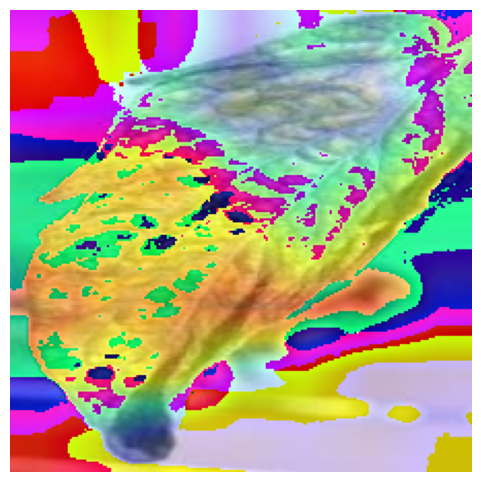

In [ ]:
# Heatmap to show the places in the image where the model has probably looked while maing predictions
# on unseen images

gradcam("ewt6.jpg")

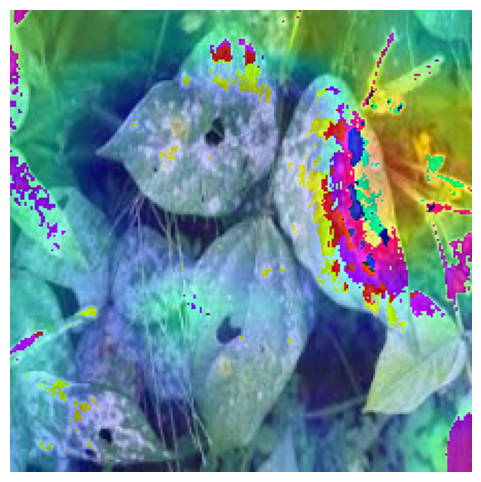

In [ ]:
gradcam("ewt1.jpg")

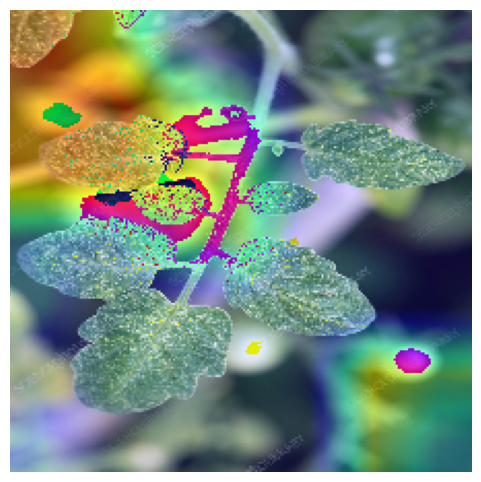

In [ ]:
  gradcam("ewt2.jpg")

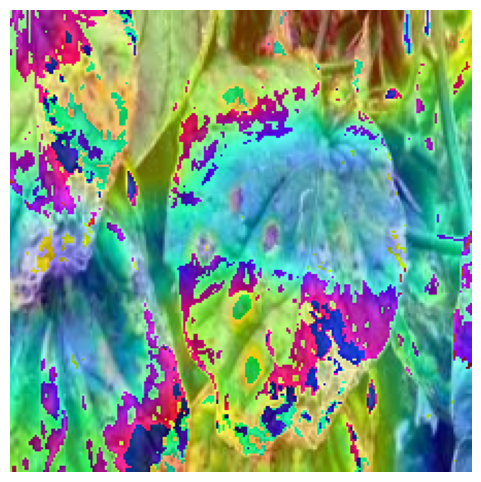

In [ ]:
  gradcam("ewt3.jpg")

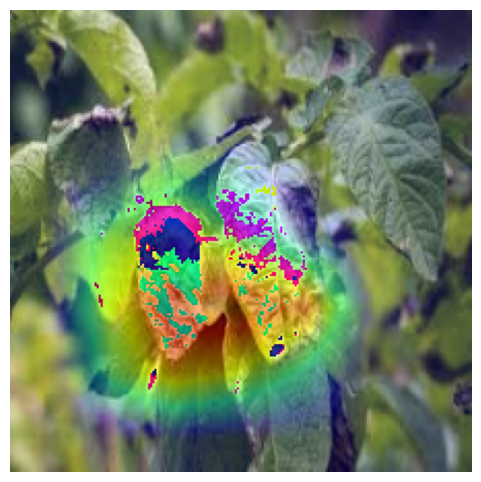

In [ ]:
  gradcam("ewt4.jpg")